In [1]:
import dask
import cftime
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import xclimate as xclim

# What LENS2 member best matches the observed ENSO phase during the transition between historical and future periods?

In [2]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=2,
    ncores=1,
    nmem='10GB',
    walltime='02:00:00'
)

account:  UWAS0155
nworkers: 2
ncores:   1
nmemory:  10GB
walltime: 02:00:00
{'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.160:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


In [5]:
# client_cluster[1]

In [167]:
xclim.close_dask_cluster(client_cluster)

# full time period

In [6]:
tperiod = slice('1980-01', '2021-12')

# masks

In [133]:
ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/AREA/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.AREA.195001-195912.nc')
area = ds.AREA.isel(time=0).drop_vars('time')

ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/lnd/proc/tseries/month_1/GPP/b.e21.BHISTcmip6.f09_g17.LE2-1301.006.clm2.h2.GPP.195001-195912.nc')
ds = ds.reindex_like(area, tolerance=1e-3, method='nearest').drop_vars('time')
a = (ds.area * 1e6).assign_attrs({'units': 'm2'})
lf = ds.landfrac
la = a * lf
lm = ~np.isnan(la)
om = ~lm
oa = area.where(om, other=0)

# load HadOI

In [8]:
hadbc = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_0.9x1.25_1850_2022_c241003.nc')
obs = hadbc.SST_cpl_prediddle.sel(time=tperiod).reindex_like(area, tolerance=1e-3, method='nearest')

# load LENS2

In [9]:
from glob import glob

xr.set_options(use_new_combine_kwarg_defaults=True)

v   = 'SST'
bb  = 'cmip6'
lens_dir = '/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1'
lens_starts = [
    '1001', '1021', '1041', '1061', '1081', '1101', '1121',
    '1141', '1161', '1181', '1231', '1251', '1281', '1301'
]

def load_member(yr: str, mem_str: str) -> xr.DataArray:
    """Open, time-concat, reindex, and mask one ensemble member."""
    files = sorted(
        glob(f'{lens_dir}/{v}/b.e21.BHIST{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc') +
        glob(f'{lens_dir}/{v}/b.e21.BSSP370{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc')
    )
    ds = xr.open_mfdataset(
        files,
        parallel=True,
        combine='by_coords',
        data_vars='minimal',
        coords='minimal',
        compat='override',
    )
    return (
        xclim.time_coord.shift_time(ds)
        .sel(time=tperiod)[v]
        .where(om)
    )

members = []
for im, yr in enumerate(lens_starts):
    print(f'- {yr}')
    if int(yr) < 1200:
        members.append(load_member(yr, str(im + 1).zfill(3)))
    else:
        for i in range(1, 11):
            print(str(i).zfill(3), end=' ')
            members.append(load_member(yr, str(i).zfill(3)))
        print()

lens = (
    xr.concat(members, dim='ens')
    .assign_coords(ens=np.arange(1, 51))
    .assign_attrs(units='deg_C')
    - 273.15
)
lens = lens.chunk({'time': -1}).persist()

- 1001
- 1021
- 1041
- 1061
- 1081
- 1101
- 1121
- 1141
- 1161
- 1181
- 1231
001 002 003 004 005 006 007 008 009 010 
- 1251
001 002 003 004 005 006 007 008 009 010 
- 1281
001 002 003 004 005 006 007 008 009 010 
- 1301
001 002 003 004 005 006 007 008 009 010 


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.20 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [160]:
mlens = lens.mean(dim='ens').chunk(time=1)
mlens.to_netcdf('/glade/campaign/univ/uwas0155/ppe/docn_sst/b.e21.cmip6.f09_g17.LE2-ens-mean.cam.h0.SST.198001-202112.nc')

# compute NINO3.4

In [23]:
def compute_nino34_rolling_reference(sst, area, rolling_nmonths=5):
    '''
    "Nino X Index computation: (a) Compute area averaged total SST from Niño X region; (b) Compute monthly climatology
    (e.g., 1950-1979) for area averaged total SST from Niño X region, and subtract climatology from area averaged total
    SST time series to obtain anomalies; (c) Smooth the anomalies with a 5-month running mean; (d) Normalize the smoothed
    values by its standard deviation over the climatological period."
    https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni#:~:text=Technical%20Notes
    '''
    sst_nino34 = sst.sel(lat=slice(-5, 5), lon=slice(190, 240))
    sst_nino34_ts = sst_nino34.weighted(area).mean(dim=['lat', 'lon'])

    sst_nino34_base_mean = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).mean().ffill('time').bfill('time'))
    )
    sst_nino34_base_std = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).std().ffill('time').bfill('time'))
    )

    sst_nino34_anom_mean_norm = (sst_nino34_ts - sst_nino34_base_mean) / sst_nino34_base_std

    nino34 = sst_nino34_anom_mean_norm.rolling(time=rolling_nmonths, center=True).mean()

    return nino34


def plot_nino34(nino34):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    ax.fill_between(
        nino34.time.data,
        nino34.where(nino34 >= 0.5).data,
        0.5,
        color = "red",
        alpha = 0.9,
    )
    ax.fill_between(
        nino34.time.data,
        nino34.where(nino34 <= -0.5).data,
        -0.5,
        color = "blue",
        alpha = 0.9,
    )

    nino34.plot(color="black", lw=0.8)
    ax.axhline(0, color="black", lw = 0.5)
    ax.axhline(0.5, color="black", linewidth = 0.5, linestyle="dotted") 
    ax.axhline(-0.5, color="black", linewidth = 0.5, linestyle="dotted")

    ax.set_title(f"NINO 3.4 Index")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("SST Anomalies (°C)")

    return fig, ax

In [12]:
lens_nino34 = compute_nino34_rolling_reference(lens, area.where(om, other=0))
obs_nino34 = compute_nino34_rolling_reference(obs, area.where(om, other=0))

In [13]:
lens_nino34 = lens_nino34.compute()
obs_nino34 = obs_nino34.compute()

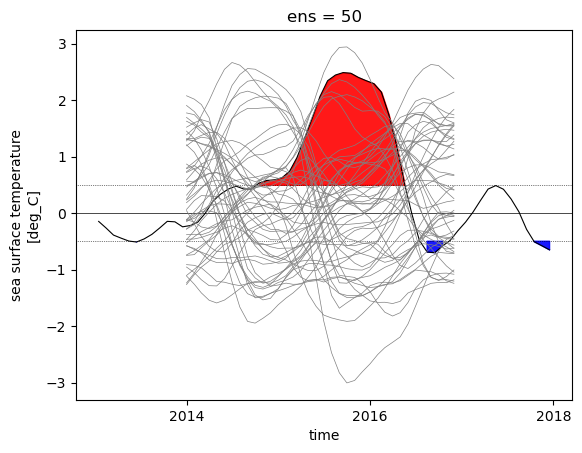

In [24]:
fig, ax = plot_nino34(obs_nino34.sel(time=slice('2013', '2017')))
for i in range(50):
    lens_nino34.sel(time=slice('2014', '2016')).isel(ens=i).plot(ax=ax, c='gray', lw=0.5)

# compute NINO3.4 error metrics

nested time periods for selection of "best" ensemble member --> first screen over longer 10-year period from 2010-2020, then select final member based on 2014-2015 branch year

In [69]:
diff_nino34 = obs_nino34 - lens_nino34.assign_coords(time=obs_nino34.time)  # simple fix for time discrepancy between start vs. midpoints of months

error_long_tperiod = slice('2009', '2020')
error_short_tperiod = slice('2014', '2015')

mae_long = np.abs(diff_nino34.sel(time=error_long_tperiod)).mean(dim='time')
mse_long = (diff_nino34.sel(time=error_long_tperiod) ** 2).mean(dim='time')
rmse_long = np.sqrt((diff_nino34.sel(time=error_long_tperiod) ** 2).mean(dim='time'))

mae_short = np.abs(diff_nino34.sel(time=error_short_tperiod)).mean(dim='time')
mse_short = (diff_nino34.sel(time=error_short_tperiod) ** 2).mean(dim='time')
rmse_short = np.sqrt((diff_nino34.sel(time=error_short_tperiod) ** 2).mean(dim='time'))

Text(0, 0.5, 'MAE [deg_C]')

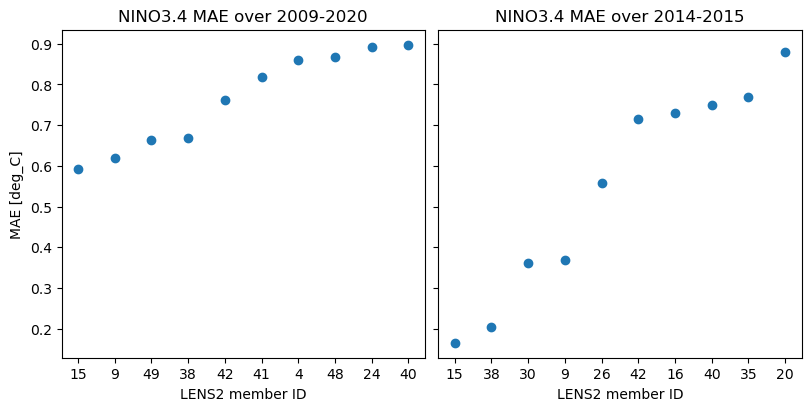

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout='constrained')

for i, error in enumerate([mae_long, mae_short]):
    error.sortby(error).assign_coords(ens=np.arange(50))[:10].plot(ax=ax[i], marker='o', lw=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('LENS2 member ID')
    ax[i].set_xticks(np.arange(50)[:10])
    ax[i].set_xticklabels(error.ens.sortby(error).data[:10]);

ax[0].set_title(f"NINO3.4 MAE over {error_long_tperiod.start}-{error_long_tperiod.stop}")
ax[1].set_title(f"NINO3.4 MAE over {error_short_tperiod.start}-{error_short_tperiod.stop}")
ax[0].set_ylabel("MAE [deg_C]")

Text(0, 0.5, 'MSE [deg_C^2]')

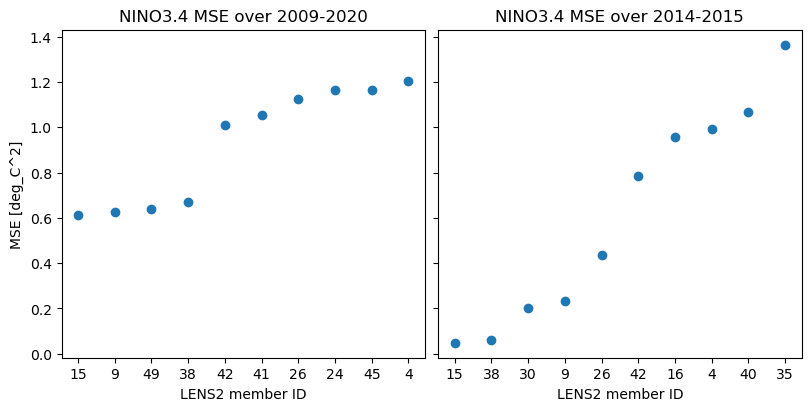

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout='constrained')

for i, error in enumerate([mse_long, mse_short]):
    error.sortby(error).assign_coords(ens=np.arange(50))[:10].plot(ax=ax[i], marker='o', lw=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('LENS2 member ID')
    ax[i].set_xticks(np.arange(50)[:10])
    ax[i].set_xticklabels(error.ens.sortby(error).data[:10]);

ax[0].set_title(f"NINO3.4 MSE over {error_long_tperiod.start}-{error_long_tperiod.stop}")
ax[1].set_title(f"NINO3.4 MSE over {error_short_tperiod.start}-{error_short_tperiod.stop}")
ax[0].set_ylabel("MSE [deg_C^2]")

Text(0, 0.5, 'RMSE [deg_C]')

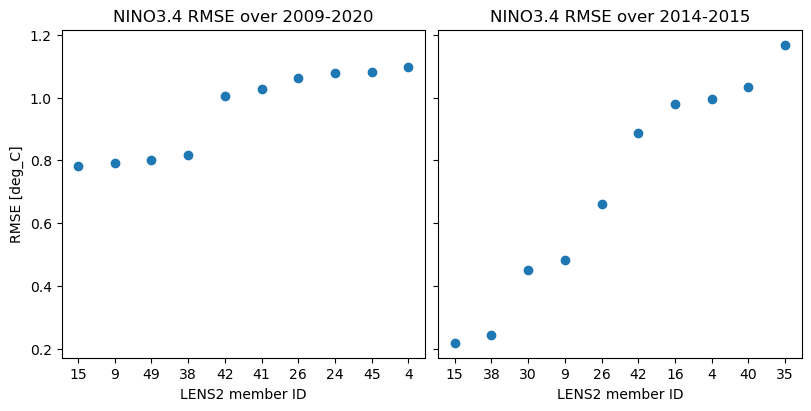

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout='constrained')

for i, error in enumerate([rmse_long, rmse_short]):
    error.sortby(error).assign_coords(ens=np.arange(50))[:10].plot(ax=ax[i], marker='o', lw=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('LENS2 member ID')
    ax[i].set_xticks(np.arange(50)[:10])
    ax[i].set_xticklabels(error.ens.sortby(error).data[:10]);

ax[0].set_title(f"NINO3.4 RMSE over {error_long_tperiod.start}-{error_long_tperiod.stop}")
ax[1].set_title(f"NINO3.4 RMSE over {error_short_tperiod.start}-{error_short_tperiod.stop}")
ax[0].set_ylabel("RMSE [deg_C]")

Text(0.5, 0.98, 'NINO3.4, members ranked by MAE over 2009-2020')

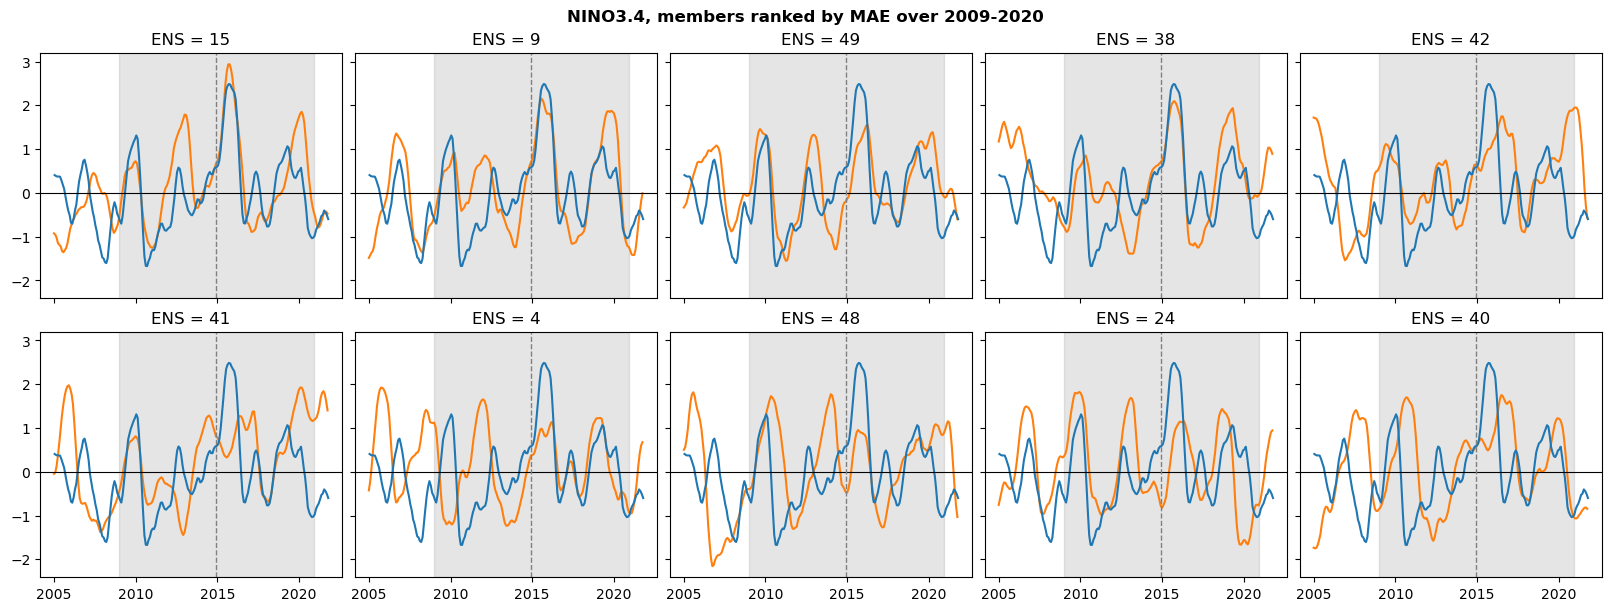

In [81]:
period = error_long_tperiod
error = mae_long

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MAE over {period.start}-{period.stop}", fontweight='bold')

Text(0.5, 0.98, 'NINO3.4, members ranked by MAE over 2014-2015')

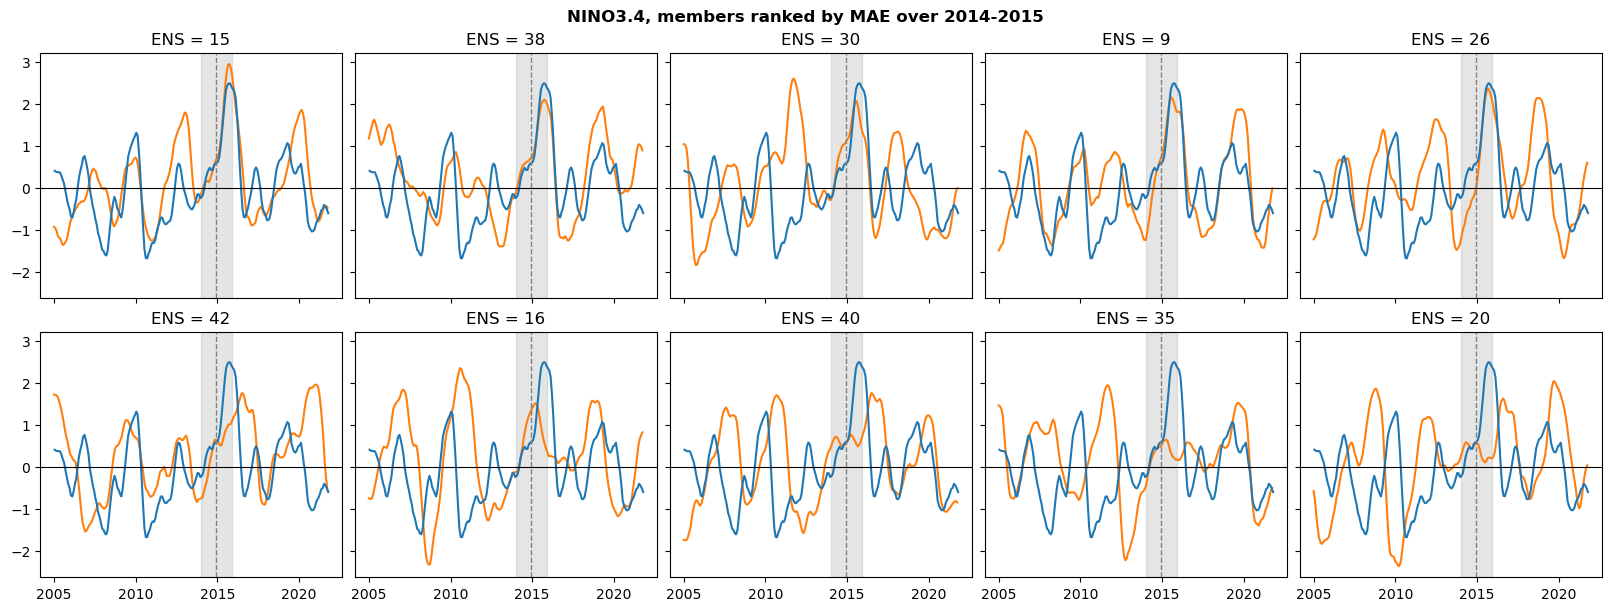

In [82]:
period = error_short_tperiod
error = mae_short

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MAE over {period.start}-{period.stop}", fontweight='bold')

Text(0.5, 0.98, 'NINO3.4, members ranked by MSE over 2009-2020')

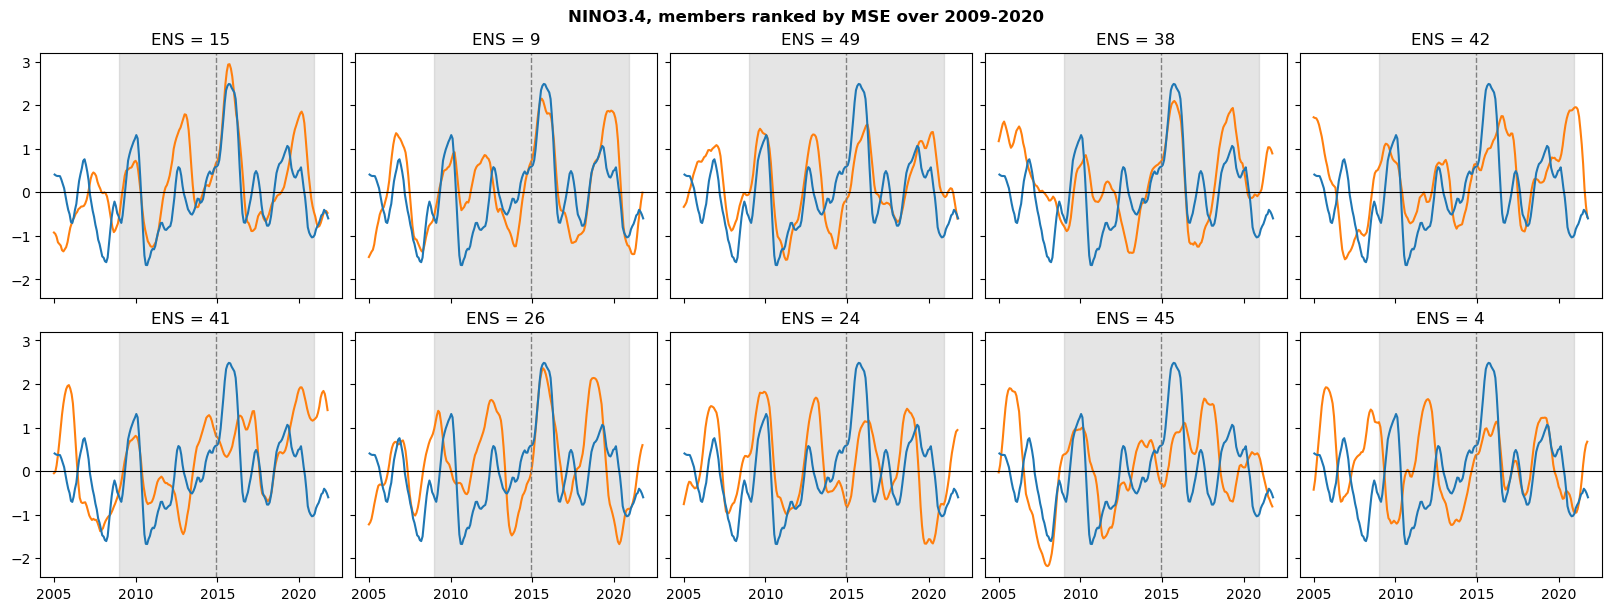

In [78]:
period = error_long_tperiod
error = mse_long

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MSE over {period.start}-{period.stop}", fontweight='bold')

Text(0.5, 0.98, 'NINO3.4, members ranked by MSE over 2014-2015')

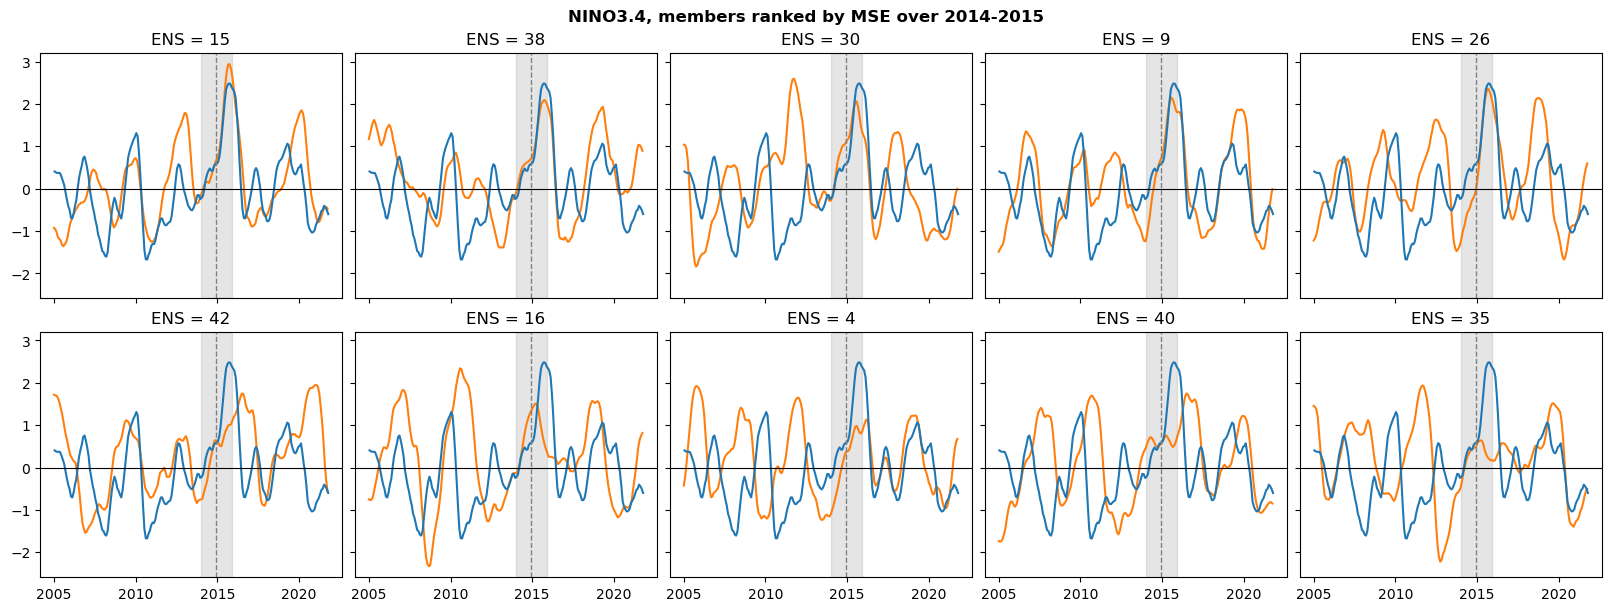

In [79]:
period = error_short_tperiod
error = mse_short

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MSE over {period.start}-{period.stop}", fontweight='bold')

# compare regions for candidate members

In [87]:
candidates = [9, 15, 30]

In [108]:
sst_region_bnds = {
    'nat': [[47, 57], [315, 335]],
    'sep': [[-62, -47], [220, 290]],
    'nep': [[35, 50], [190, 220]],
    'npa': [[30, 50], [150, 230]],
    'ind': [[-15, 5], [60, 90]],
    'sop': [[-62, -47], [100, 140]],
    'so': [[-90, -50], [0, 360]],
}

sst_region_names = {
    'nat': 'N. Atlantic box',
    'sep': 'S. East Pacific box',
    'nep': 'N. East Pacific box',
    'npa': 'N. Pacific box',
    'ind': 'Indian Ocean box',
    'sop': 'Southern Ocean box',
    'so': 'Southern Ocean',
}

sst_regions = {}
for name, bnds in sst_region_bnds.items():
    lat_bnds = bnds[0]
    lon_bnds = bnds[1]
    reg = obs.isel(time=0).drop_vars('time')
    reg = ((reg.lat >= lat_bnds[0]) & (reg.lat < lat_bnds[1]) & (reg.lon >= lon_bnds[0]) & (reg.lon < lon_bnds[1]))
    sst_regions[name] = reg.where(om).rename(name)

N. Atlantic box annual stddev
  HadOI =  0.526
  LENS09 =  0.435
  LENS15 =  0.456
  LENS30 =  0.405
S. East Pacific box annual stddev
  HadOI =  0.262
  LENS09 =  0.274
  LENS15 =  0.371
  LENS30 =  0.446
N. East Pacific box annual stddev
  HadOI =  0.531
  LENS09 =  0.586
  LENS15 =  0.689
  LENS30 =  0.845
N. Pacific box annual stddev
  HadOI =  0.379
  LENS09 =  0.575
  LENS15 =  0.611
  LENS30 =  0.684
Indian Ocean box annual stddev
  HadOI =  0.252
  LENS09 =  0.321
  LENS15 =  0.313
  LENS30 =  0.329
Southern Ocean box annual stddev
  HadOI =  0.192
  LENS09 =  0.234
  LENS15 =  0.210
  LENS30 =  0.251
Southern Ocean annual stddev
  HadOI =  0.102
  LENS09 =  0.123
  LENS15 =  0.131
  LENS30 =  0.165


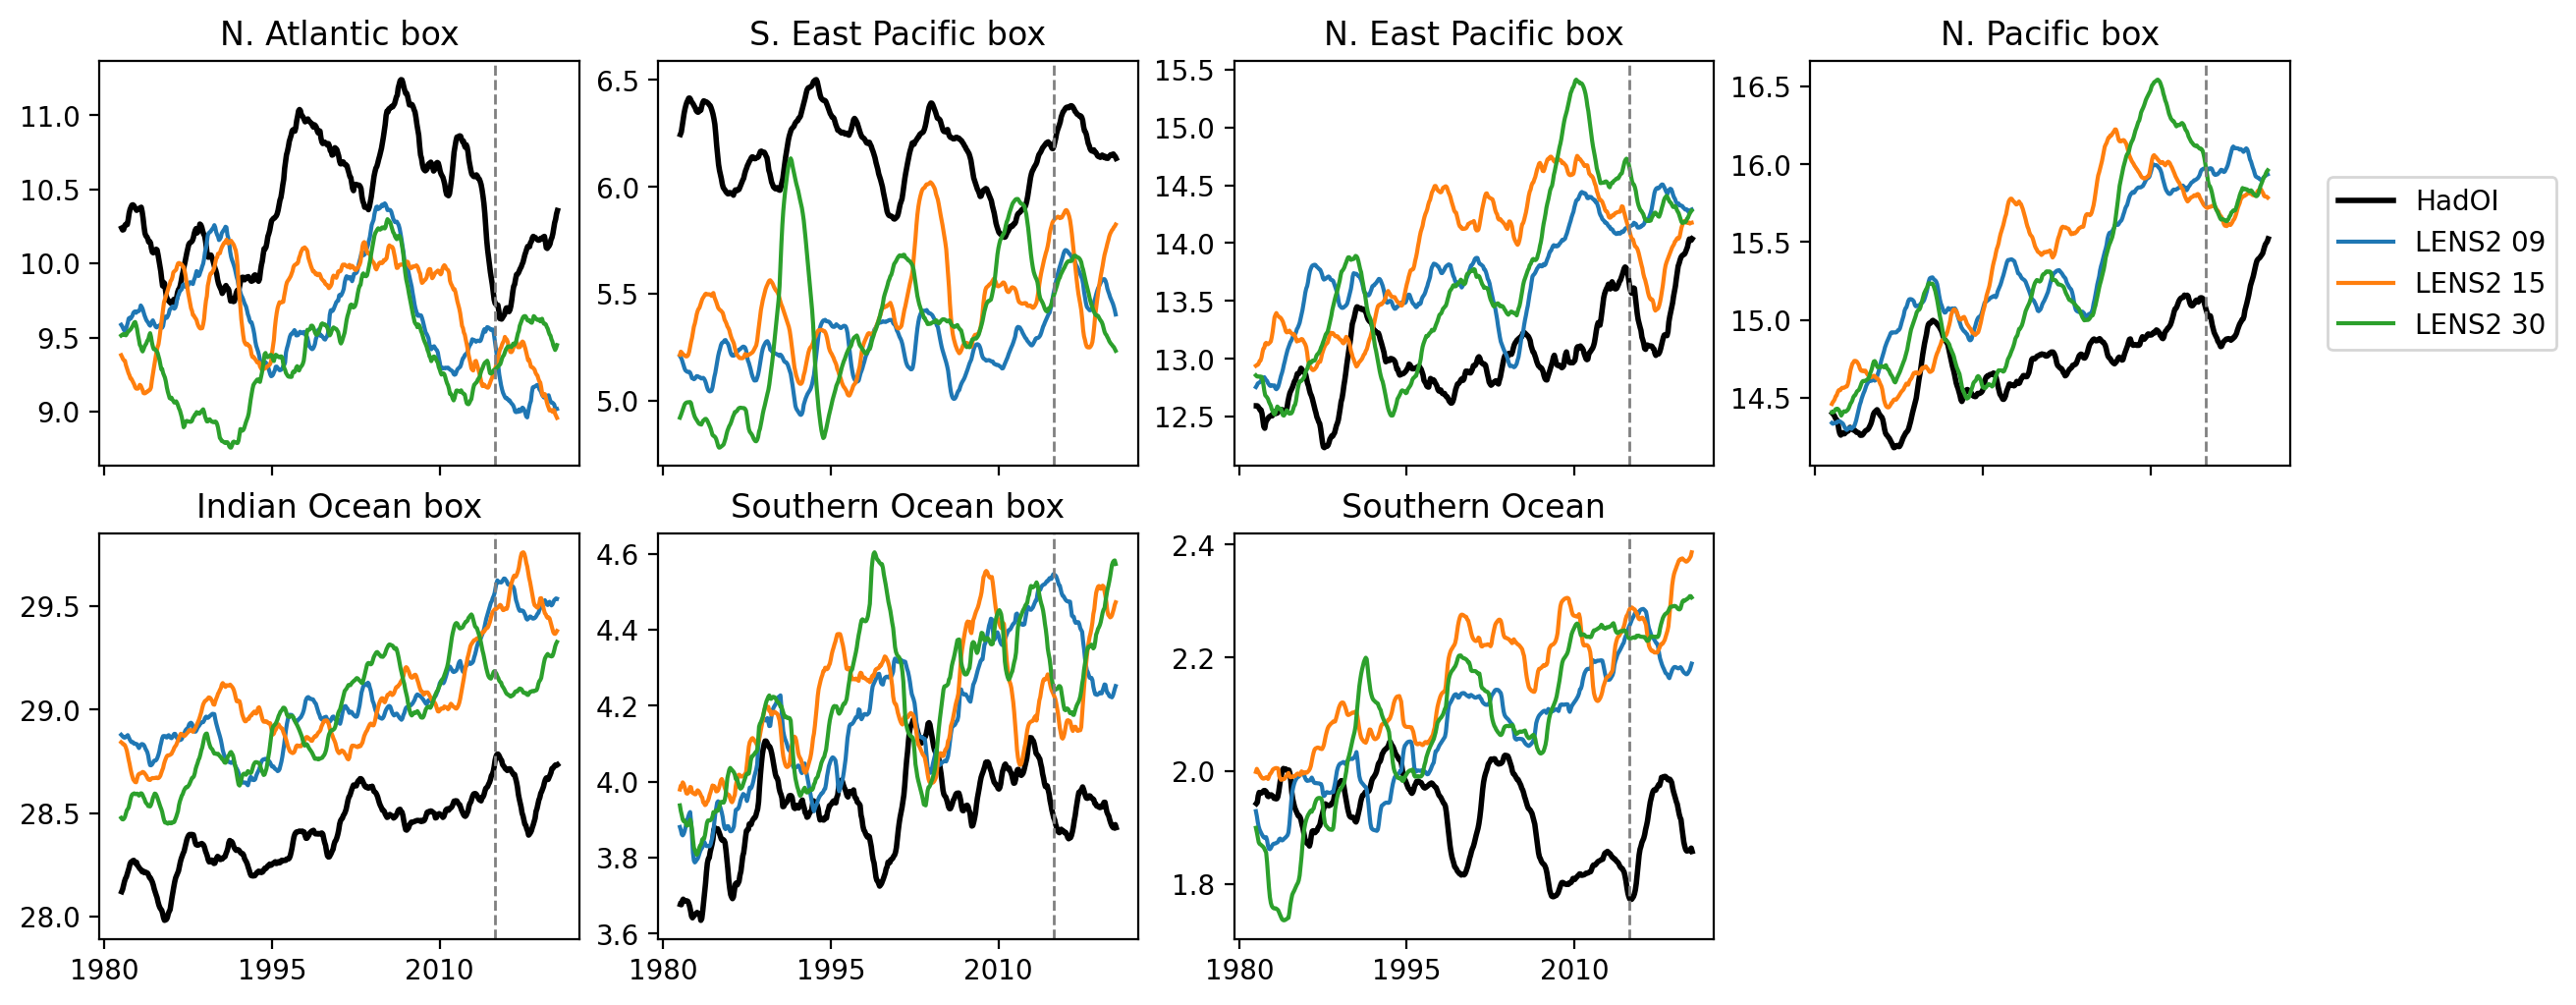

In [166]:
smooth_months = 36

fig, axs = plt.subplots(2, 4, figsize=(13, 5), sharex=True, layout='constrained', dpi=200)
ax = axs.flatten()

for i, (name, reg) in enumerate(sst_regions.items()):
    obs_reg_roll = obs.where(reg).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()
    lens_reg_roll = lens.sel(ens=candidates).where(reg).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()

    obs_reg_ann = obs.where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()
    lens_reg_ann = lens.sel(ens=candidates).where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()

    obs_reg_roll.plot(ax=ax[i], c='k', ls='-', lw=2, label='HadOI')
    for ens in candidates:
        lens_reg_roll.sel(ens=ens).plot(ax=ax[i], ls='-', label=f'LENS2 {str(ens).zfill(2)}')
    ax[i].axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(sst_region_names[name])

    print(sst_region_names[name], 'annual stddev')
    print(f'  HadOI = {obs_reg_ann.std(dim='year').values: 0.3f}')
    for ens in candidates:
        print(f'  LENS{str(ens).zfill(2)} = {lens_reg_ann.sel(ens=ens).std(dim='year').values: 0.3f}')

ax[3].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax[-1].remove()